# Lab 8 - Segmentation

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, June 6th (23:59)**

------
**Objective:** In this lab you will go from raw images to pixel-precise segmentation masks.  
You will explore classical methods, use the Segment Anything Model (SAM ViT-B) with different prompt strategies, implement evaluation metrics from scratch, and interpret your results.

**Dataset:** Oxford-IIIT Pets (5-breed subset, 50 images)  
**Model:** SAM ViT-B (~375 MB) — the lightweight version of Meta's SAM

---
>⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.


---
## Part 0 — Installation and Setup
Run the cells below once. They install all required libraries and download the SAM ViT-B checkpoint.


In [1]:
# Install required libraries
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install opencv-python-headless matplotlib numpy torchvision tqdm -q
print("✅ Libraries installed")


  Preparing metadata (setup.py) ... done
✅ Libraries installed


In [2]:
import os

# Download SAM ViT-B checkpoint (~375 MB)
checkpoint_path = "sam_vit_b_01ec64.pth"
if not os.path.exists(checkpoint_path):
    print("Downloading SAM ViT-B checkpoint (~375 MB) ...")
    !wget -q --show-progress https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    print("✅ Checkpoint downloaded")
else:
    print("✅ Checkpoint already exists")


sam_vit_b_01ec64.pt 100%[===================>] 357.67M   260MB/s    in 1.4s    
✅ Checkpoint downloaded


In [3]:
# Download Oxford-IIIT Pets dataset (images + annotations)
import os

if not os.path.exists("oxford-iiit-pet"):
    os.makedirs("oxford-iiit-pet", exist_ok=True)
    print("Downloading Oxford-IIIT Pets images ...")
    !wget -q --show-progress https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
    !wget -q --show-progress https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
    !tar -xzf images.tar.gz -C oxford-iiit-pet/
    !tar -xzf annotations.tar.gz -C oxford-iiit-pet/
    print("✅ Dataset downloaded and extracted")
else:
    print("✅ Dataset already exists")


images.tar.gz       100%[===================>] 755.23M  14.1MB/s    in 55s     
annotations.tar.gz  100%[===================>]  18.28M  11.1MB/s    in 1.7s    
✅ Dataset downloaded and extracted


In [4]:
# Global imports — run this cell before anything else
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch
import os
import random
from pathlib import Path
from PIL import Image

# SAM imports
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

# Reproducibility
random.seed(42)
np.random.seed(42)

print("✅ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


✅ All imports successful
PyTorch version: 2.11.0+cu128
Device: cuda


---
## Part 1 — Data Exploration

Before building any model, we need to understand our data.  
The Oxford-IIIT Pets dataset contains images of cats and dogs with **trimap masks**.

A trimap has three pixel values:
- `1` → foreground (the pet)
- `2` → background
- `3` → boundary / uncertain region

We will work with a **5-breed subset** of 50 images for speed.


In [5]:
# ── Helper: load dataset paths (5 breeds, 10 images each) ──────────────────
BREEDS = ["Abyssinian", "Bengal", "Bombay", "british_shorthair", "german_shorthaired"]
IMG_DIR  = Path("oxford-iiit-pet/images")
MASK_DIR = Path("oxford-iiit-pet/annotations/trimaps")

def load_dataset(breeds=BREEDS, n_per_breed=10):
    """Return list of (image_path, mask_path) tuples for selected breeds."""
    pairs = []
    for breed in breeds:
        imgs = sorted(IMG_DIR.glob(f"{breed}_*.jpg"))[:n_per_breed]
        for img_path in imgs:
            mask_path = MASK_DIR / (img_path.stem + ".png")
            if mask_path.exists():
                pairs.append((img_path, mask_path))
    random.shuffle(pairs)
    return pairs

dataset = load_dataset()
print(f"✅ Dataset loaded: {len(dataset)} image-mask pairs")


✅ Dataset loaded: 40 image-mask pairs


In [6]:
# ── Helper: load image and mask ─────────────────────────────────────────────
def load_image(path):
    """Load image as RGB numpy array."""
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_mask(path):
    """Load trimap mask as numpy array (values: 1, 2, 3)."""
    return np.array(Image.open(path))

# Quick sanity check
img, mask = load_image(dataset[0][0]), load_mask(dataset[0][1])
print(f"Image shape : {img.shape}  dtype: {img.dtype}")
print(f"Mask shape  : {mask.shape}  unique values: {np.unique(mask)}")


Image shape : (448, 500, 3)  dtype: uint8
Mask shape  : (448, 500)  unique values: [1 2 3]


### TODO 1 — Visualize 5 images with their ground truth masks
Complete the function below to display 5 random image-mask pairs side by side.  
Each row should show: **original image | trimap mask | colored overlay**.

**Hint:** use `plt.imshow()`. For the overlay, you can use a colormap like `'jet'` on the mask.


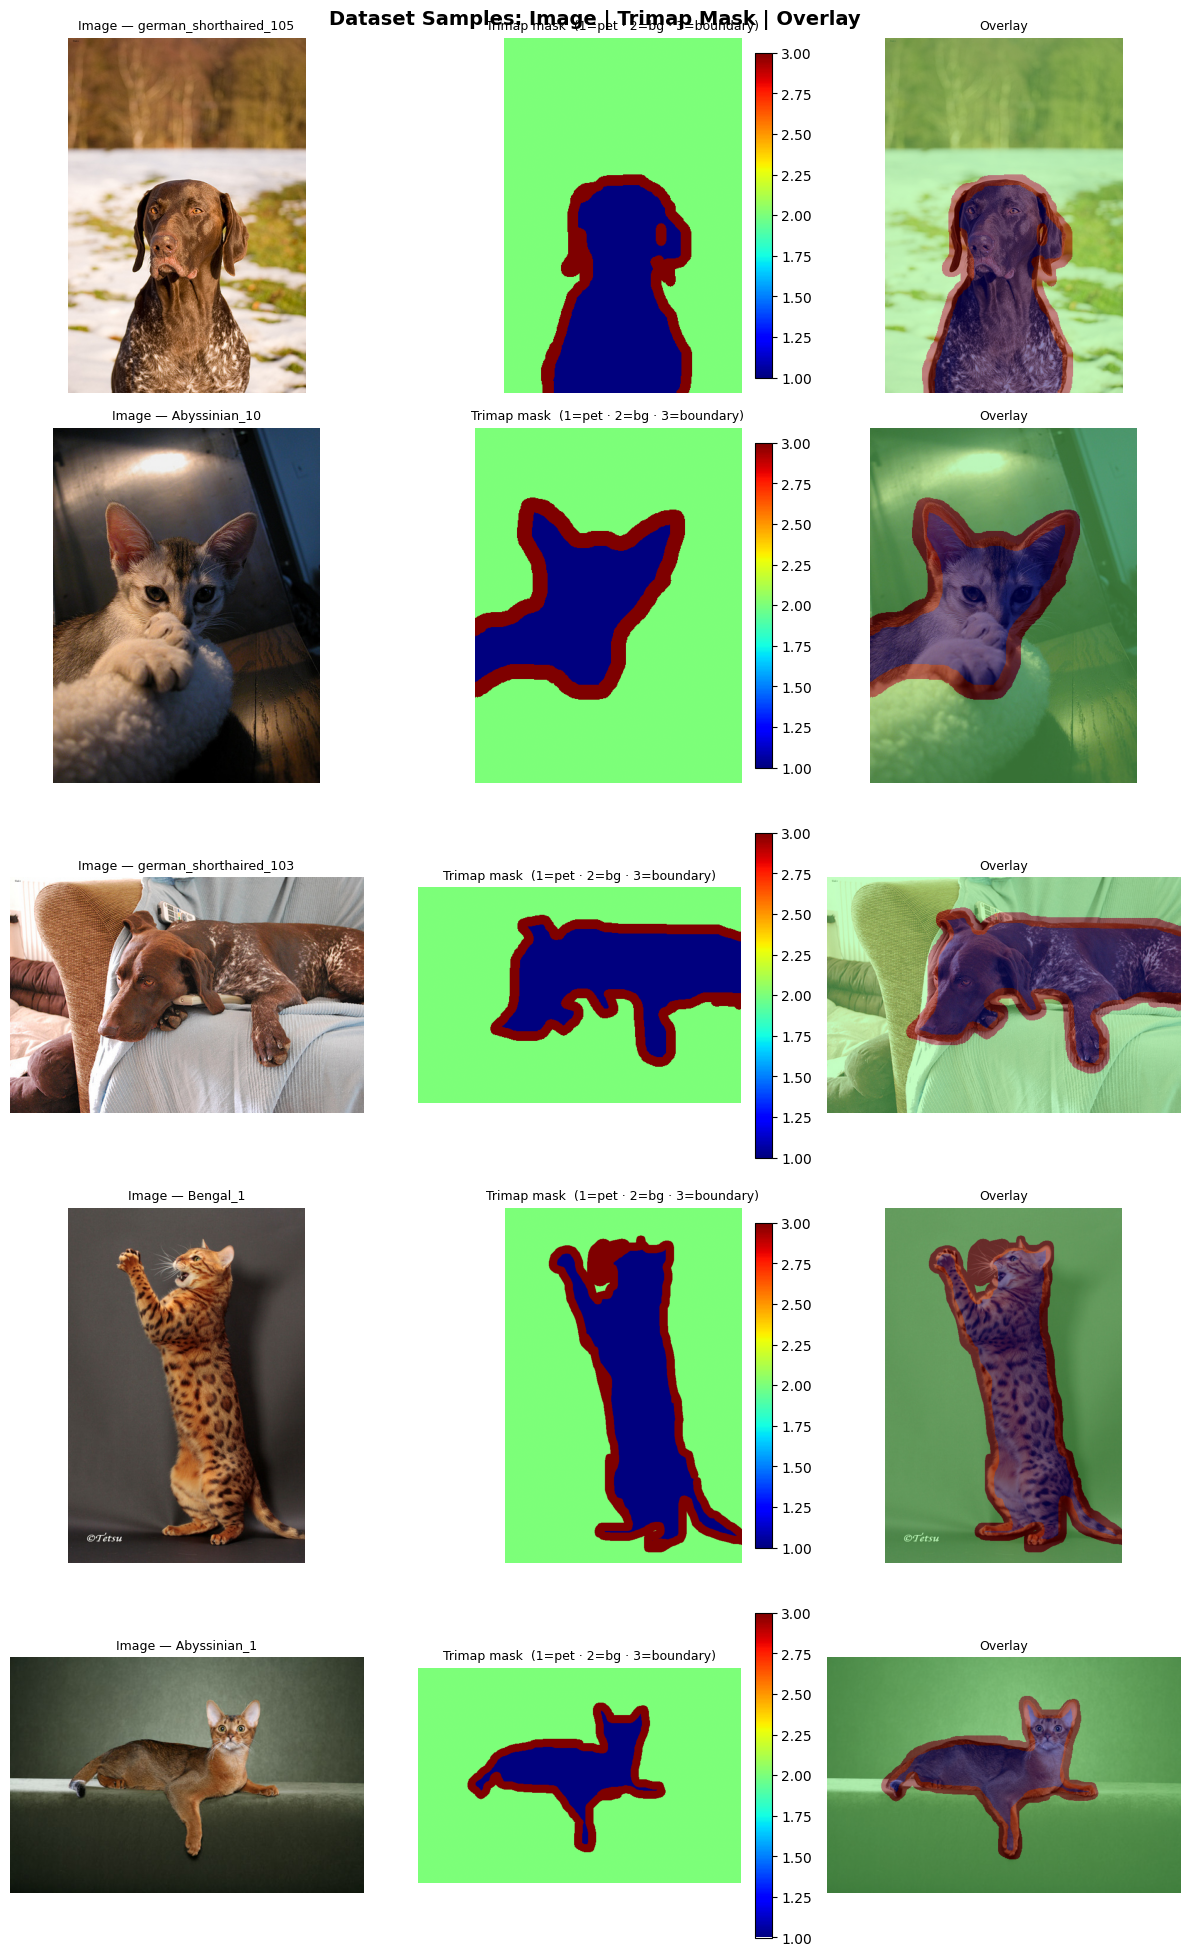

In [7]:
def visualize_samples(dataset, n=5):
    """
    Display n samples from the dataset.
    Each row: original image | trimap mask | overlay
    """
    samples = random.sample(dataset, n)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle("Dataset Samples: Image | Trimap Mask | Overlay", fontsize=14, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(samples):
        img  = load_image(img_path)
        mask = load_mask(mask_path)

        # ── TODO 1 ──────────────────────────────────────────────────────────
        # Column 0: original image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image — {img_path.stem}", fontsize=9)
        axes[i, 0].axis("off")

        # Column 1: trimap mask with 'jet' colormap
        # vmin/vmax fix the colour scale to the known trimap range [1, 3]
        im = axes[i, 1].imshow(mask, cmap="jet", vmin=1, vmax=3)
        axes[i, 1].set_title("Trimap mask  (1=pet · 2=bg · 3=boundary)", fontsize=9)
        axes[i, 1].axis("off")
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

        # Column 2: semi-transparent coloured overlay on the original image
        axes[i, 2].imshow(img)
        axes[i, 2].imshow(mask, cmap="jet", vmin=1, vmax=3, alpha=0.45)
        axes[i, 2].set_title("Overlay", fontsize=9)
        axes[i, 2].axis("off")
        # ────────────────────────────────────────────────────────────────────

    plt.tight_layout()
    plt.show()

visualize_samples(dataset, n=5)

### TODO 2 — Convert trimap to binary mask
The trimap has values 1 (pet), 2 (background), 3 (boundary).  
Convert it to a **binary mask**: `1` where the pixel is pet, `0` everywhere else.  
Treat boundary pixels (value 3) as foreground.


In [8]:
def trimap_to_binary(trimap):
    """
    Convert trimap mask to binary foreground mask.
    Args:
        trimap: numpy array with values 1 (pet), 2 (background), 3 (boundary)
    Returns:
        binary mask: numpy array with values 0 and 1
    """
    # ── TODO 2 ──────────────────────────────────────────────────────────────
    # Pixels with value 1 (pet) or 3 (boundary) → foreground (1)
    # Pixels with value 2 (background)           → background (0)
    binary = np.where((trimap == 1) | (trimap == 3), 1, 0).astype(np.uint8)
    return binary
    # ────────────────────────────────────────────────────────────────────────

# Test
sample_mask = load_mask(dataset[0][1])
binary = trimap_to_binary(sample_mask)
print(f"Trimap unique values : {np.unique(sample_mask)}")
print(f"Binary unique values : {np.unique(binary)}")
print(f"Foreground pixels    : {binary.sum()} / {binary.size} ({100*binary.mean():.1f}%)")

Trimap unique values : [1 2 3]
Binary unique values : [0 1]
Foreground pixels    : 113634 / 224000 (50.7%)


### TODO 3 — Plot foreground pixel distribution
For each of the 50 images, compute the percentage of foreground pixels.  
Plot a **bar chart** showing this distribution across all images.  
Add a horizontal line showing the mean foreground percentage.


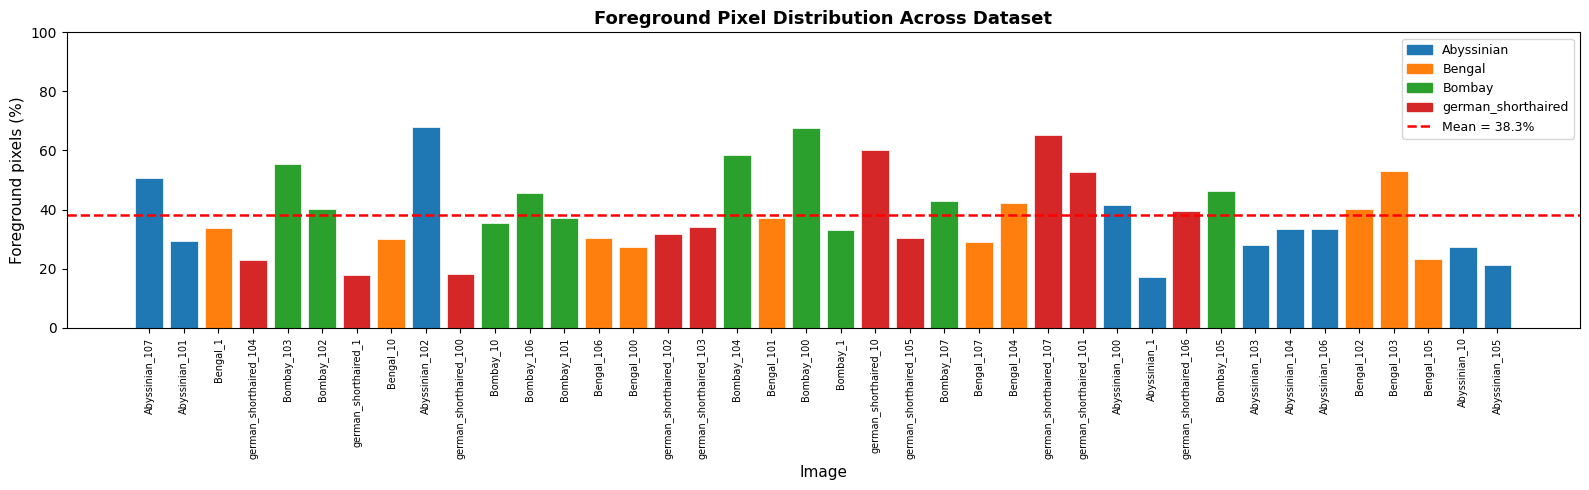

Mean foreground  : 38.28%
Min foreground   : 17.18%  → Abyssinian_1
Max foreground   : 67.95%  → Abyssinian_102


In [9]:
def plot_foreground_distribution(dataset):
    """
    For each image compute % of foreground pixels and plot as bar chart.
    """
    # ── TODO 3 ──────────────────────────────────────────────────────────────
    # 1. Loop over dataset, load each mask, convert to binary, compute fg %
    fg_percentages = []
    image_names    = []

    for img_path, mask_path in dataset:
        trimap = load_mask(mask_path)
        binary = trimap_to_binary(trimap)
        fg_pct = 100.0 * binary.mean()
        fg_percentages.append(fg_pct)
        image_names.append(img_path.stem)

    # 2. Build the bar chart
    fig, ax = plt.subplots(figsize=(16, 5))

    # Colour bars by breed for visual grouping
    cmap   = plt.get_cmap("tab10")
    breeds = [name.rsplit("_", 1)[0] for name in image_names]
    unique_breeds = sorted(set(breeds))
    breed_colour  = {b: cmap(i) for i, b in enumerate(unique_breeds)}
    bar_colours   = [breed_colour[b] for b in breeds]

    x = np.arange(len(fg_percentages))
    ax.bar(x, fg_percentages, color=bar_colours, edgecolor="white", linewidth=0.5)

    # 3. Mean line
    mean_fg = np.mean(fg_percentages)
    ax.axhline(mean_fg, color="red", linestyle="--", linewidth=1.8,
               label=f"Mean = {mean_fg:.1f}%")

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(image_names, rotation=90, fontsize=7)
    ax.set_xlabel("Image", fontsize=11)
    ax.set_ylabel("Foreground pixels (%)", fontsize=11)
    ax.set_title("Foreground Pixel Distribution Across Dataset", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 100)

    # Legend: breeds + mean line
    legend_handles = [patches.Patch(color=breed_colour[b], label=b) for b in unique_breeds]
    legend_handles.append(plt.Line2D([0], [0], color="red", linestyle="--",
                                     linewidth=1.8, label=f"Mean = {mean_fg:.1f}%"))
    ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.show()

    print(f"Mean foreground  : {mean_fg:.2f}%")
    print(f"Min foreground   : {min(fg_percentages):.2f}%  → {image_names[np.argmin(fg_percentages)]}")
    print(f"Max foreground   : {max(fg_percentages):.2f}%  → {image_names[np.argmax(fg_percentages)]}")
    # ────────────────────────────────────────────────────────────────────────

plot_foreground_distribution(dataset)

 The distribution chart reveals some interesting patterns:
- **Mean of 38.3%**: pets typically occupy just over a third of each image
- **Range is wide: 17% → 68%**: some images are tight close-ups (Abyssinian_102 at 68%), others have the pet as a small subject (Abyssinian_1 at 17%)
- **Bombay cats** (green) tend to cluster above the mean, suggesting their photos are more zoomed-in.

---
## Part 2 — Classical Segmentation: Why Naive Methods Fail

Before using SAM, we try two classical segmentation approaches:
- **Color thresholding** in HSV colorspace
- **Otsu's automatic thresholding** on grayscale

These methods require no learning, no data
But they have fundamental limitations, you will measure exactly how limited they are.


### TODO 4 — Color thresholding in HSV
Convert the image to HSV and threshold on the **saturation channel** to isolate the pet.  
Pets typically have higher saturation than backgrounds like grass or walls.


In [10]:

def color_threshold_segment(image_rgb):
    """
    Segment foreground using HSV saturation thresholding.
    Args:
        image_rgb: numpy array (H, W, 3) in RGB
    Returns:
        binary mask: numpy array (H, W) with values 0 and 1
    """
    # ── TODO 4 ──────────────────────────────────────────────────────────────
    # 1. Convert RGB → HSV  (cv2 works in BGR, so RGB→BGR→HSV)
    bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    # 2. Extract the saturation channel (index 1); range [0, 255] in cv2
    saturation = hsv[:, :, 1]

    # 3. Threshold: pixels with saturation > 60 are foreground
    binary = (saturation > 60).astype(np.uint8)

    # 4. Return binary mask (0 or 1)
    return binary
    # ────────────────────────────────────────────────────────────────────────

# Test on one image
test_img = load_image(dataset[0][0])
pred = color_threshold_segment(test_img)
print(f"Predicted mask shape: {pred.shape}, unique: {np.unique(pred)}")

Predicted mask shape: (448, 500), unique: [0 1]


### TODO 5 — Morphological cleaning
Raw thresholding produces noisy masks with holes and isolated pixels.  
Apply **erosion followed by dilation** (opening) to clean the mask.


In [11]:
def morphological_clean(binary_mask, kernel_size=5, iterations=2):
    """
    Clean a binary mask using morphological opening (erosion then dilation).
    Args:
        binary_mask : numpy array (H, W) with values 0 and 1
        kernel_size : size of the structuring element
        iterations  : number of times to apply each operation
    Returns:
        cleaned binary mask (0 or 1)
    """
    # ── TODO 5 ──────────────────────────────────────────────────────────────
    # 1. Square structuring element
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (kernel_size, kernel_size)
    )

    # 2. Convert to uint8 in [0, 255] so cv2 morph ops work correctly
    mask_u8 = (binary_mask * 255).astype(np.uint8)

    # 3. Opening = erosion → dilation  (removes small isolated noise blobs)
    eroded  = cv2.erode(mask_u8,  kernel, iterations=iterations)
    dilated = cv2.dilate(eroded,  kernel, iterations=iterations)

    # 4. Convert back to binary (0 or 1)
    return (dilated > 0).astype(np.uint8)

### TODO 6 — Visualize thresholding results
Show 3 images with: **original | predicted mask | colored overlay on image**.


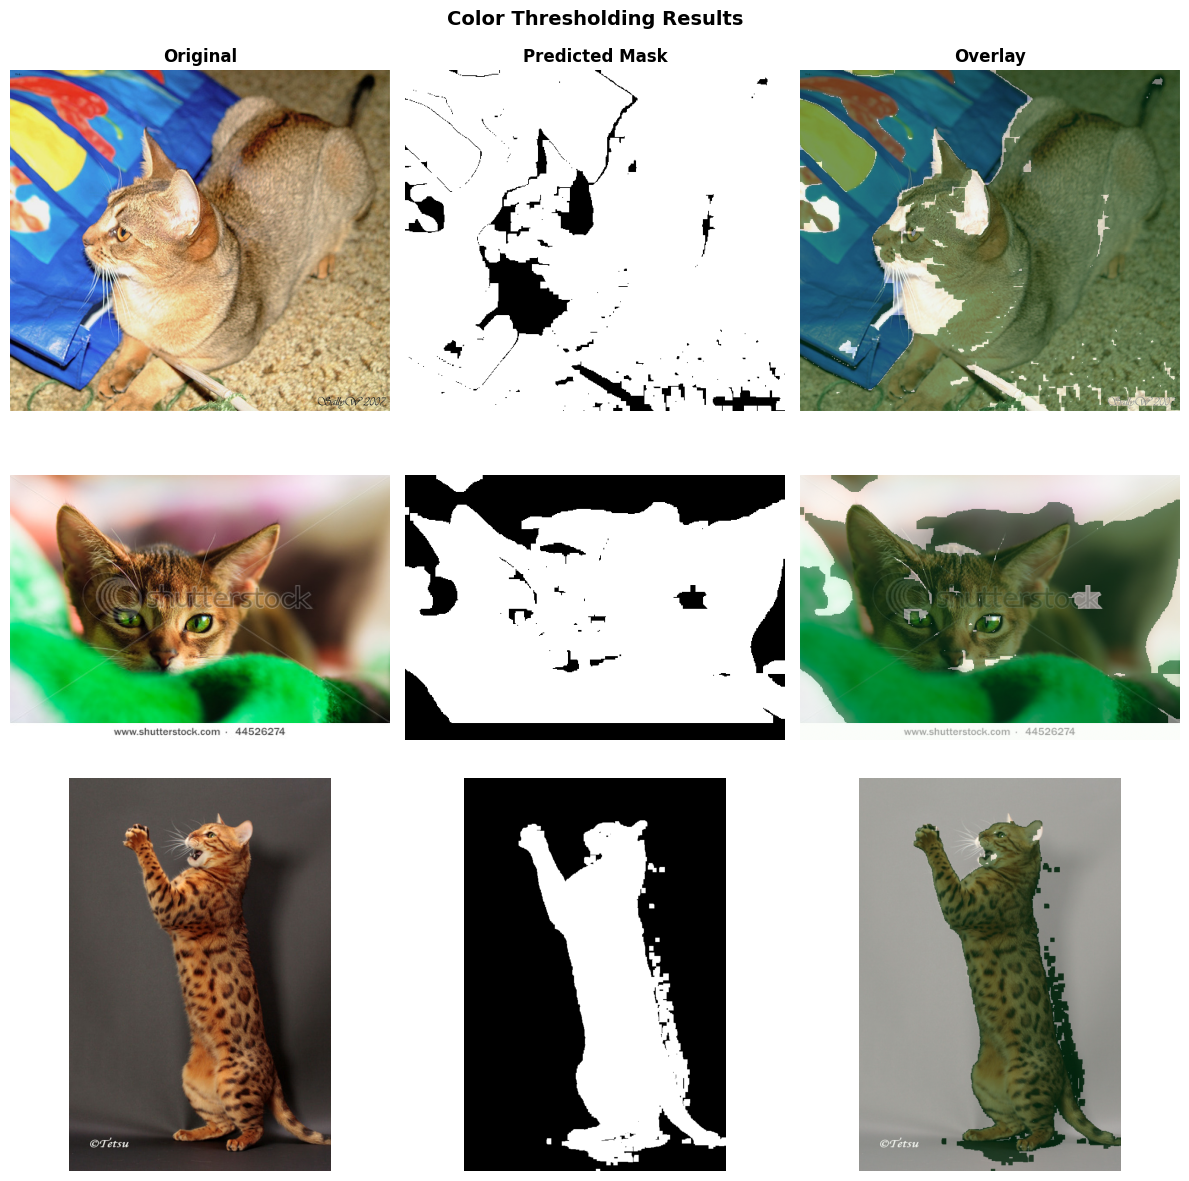

In [12]:
def visualize_classical(dataset, segment_fn, clean_fn, title, n=3):
    """
    Visualize classical segmentation results.
    Each row: original image | predicted mask | overlay
    """
    samples = dataset[:n]
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Column headers on the first row only
    for j, col_title in enumerate(["Original", "Predicted Mask", "Overlay"]):
        axes[0, j].set_title(col_title, fontsize=12, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(samples):
        img  = load_image(img_path)
        pred = clean_fn(segment_fn(img))

        # ── TODO 6 ──────────────────────────────────────────────────────────
        # Column 0: original image
        axes[i, 0].imshow(img)
        axes[i, 0].set_ylabel(img_path.stem, fontsize=8, rotation=0,
                              labelpad=60, va='center')
        axes[i, 0].axis("off")

        # Column 1: predicted binary mask (grayscale)
        axes[i, 1].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].axis("off")

        # Column 2: semi-transparent overlay (mask tinted green over image)
        axes[i, 2].imshow(img)
        axes[i, 2].imshow(pred, cmap="Greens", alpha=0.5, vmin=0, vmax=1)
        axes[i, 2].axis("off")
        # ────────────────────────────────────────────────────────────────────

    plt.tight_layout()
    plt.show()

visualize_classical(dataset, color_threshold_segment, morphological_clean,
                    "Color Thresholding Results", n=3)

### TODO 7 — Otsu's automatic thresholding
Otsu's method automatically finds the optimal threshold on the **grayscale** image.  
It requires no manual parameter tuning.


In [13]:
def otsu_segment(image_rgb):
    """
    Segment foreground using Otsu's automatic thresholding on grayscale.
    Args:
        image_rgb: numpy array (H, W, 3) in RGB
    Returns:
        binary mask: numpy array (H, W) with values 0 and 1
    """
    # ── TODO 7 ──────────────────────────────────────────────────────────────
    # 1. Convert RGB → grayscale
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    # 2. Otsu's method: cv2 auto-picks the optimal threshold.
    #    THRESH_BINARY + THRESH_OTSU → pixels above threshold become 255.
    _, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 3. Return binary mask (0 or 1)
    return (thresh > 0).astype(np.uint8)

### TODO 8 — Compare methods side by side
Display 5 images as a grid: **original | color threshold | Otsu | ground truth**  
4 columns, 5 rows.


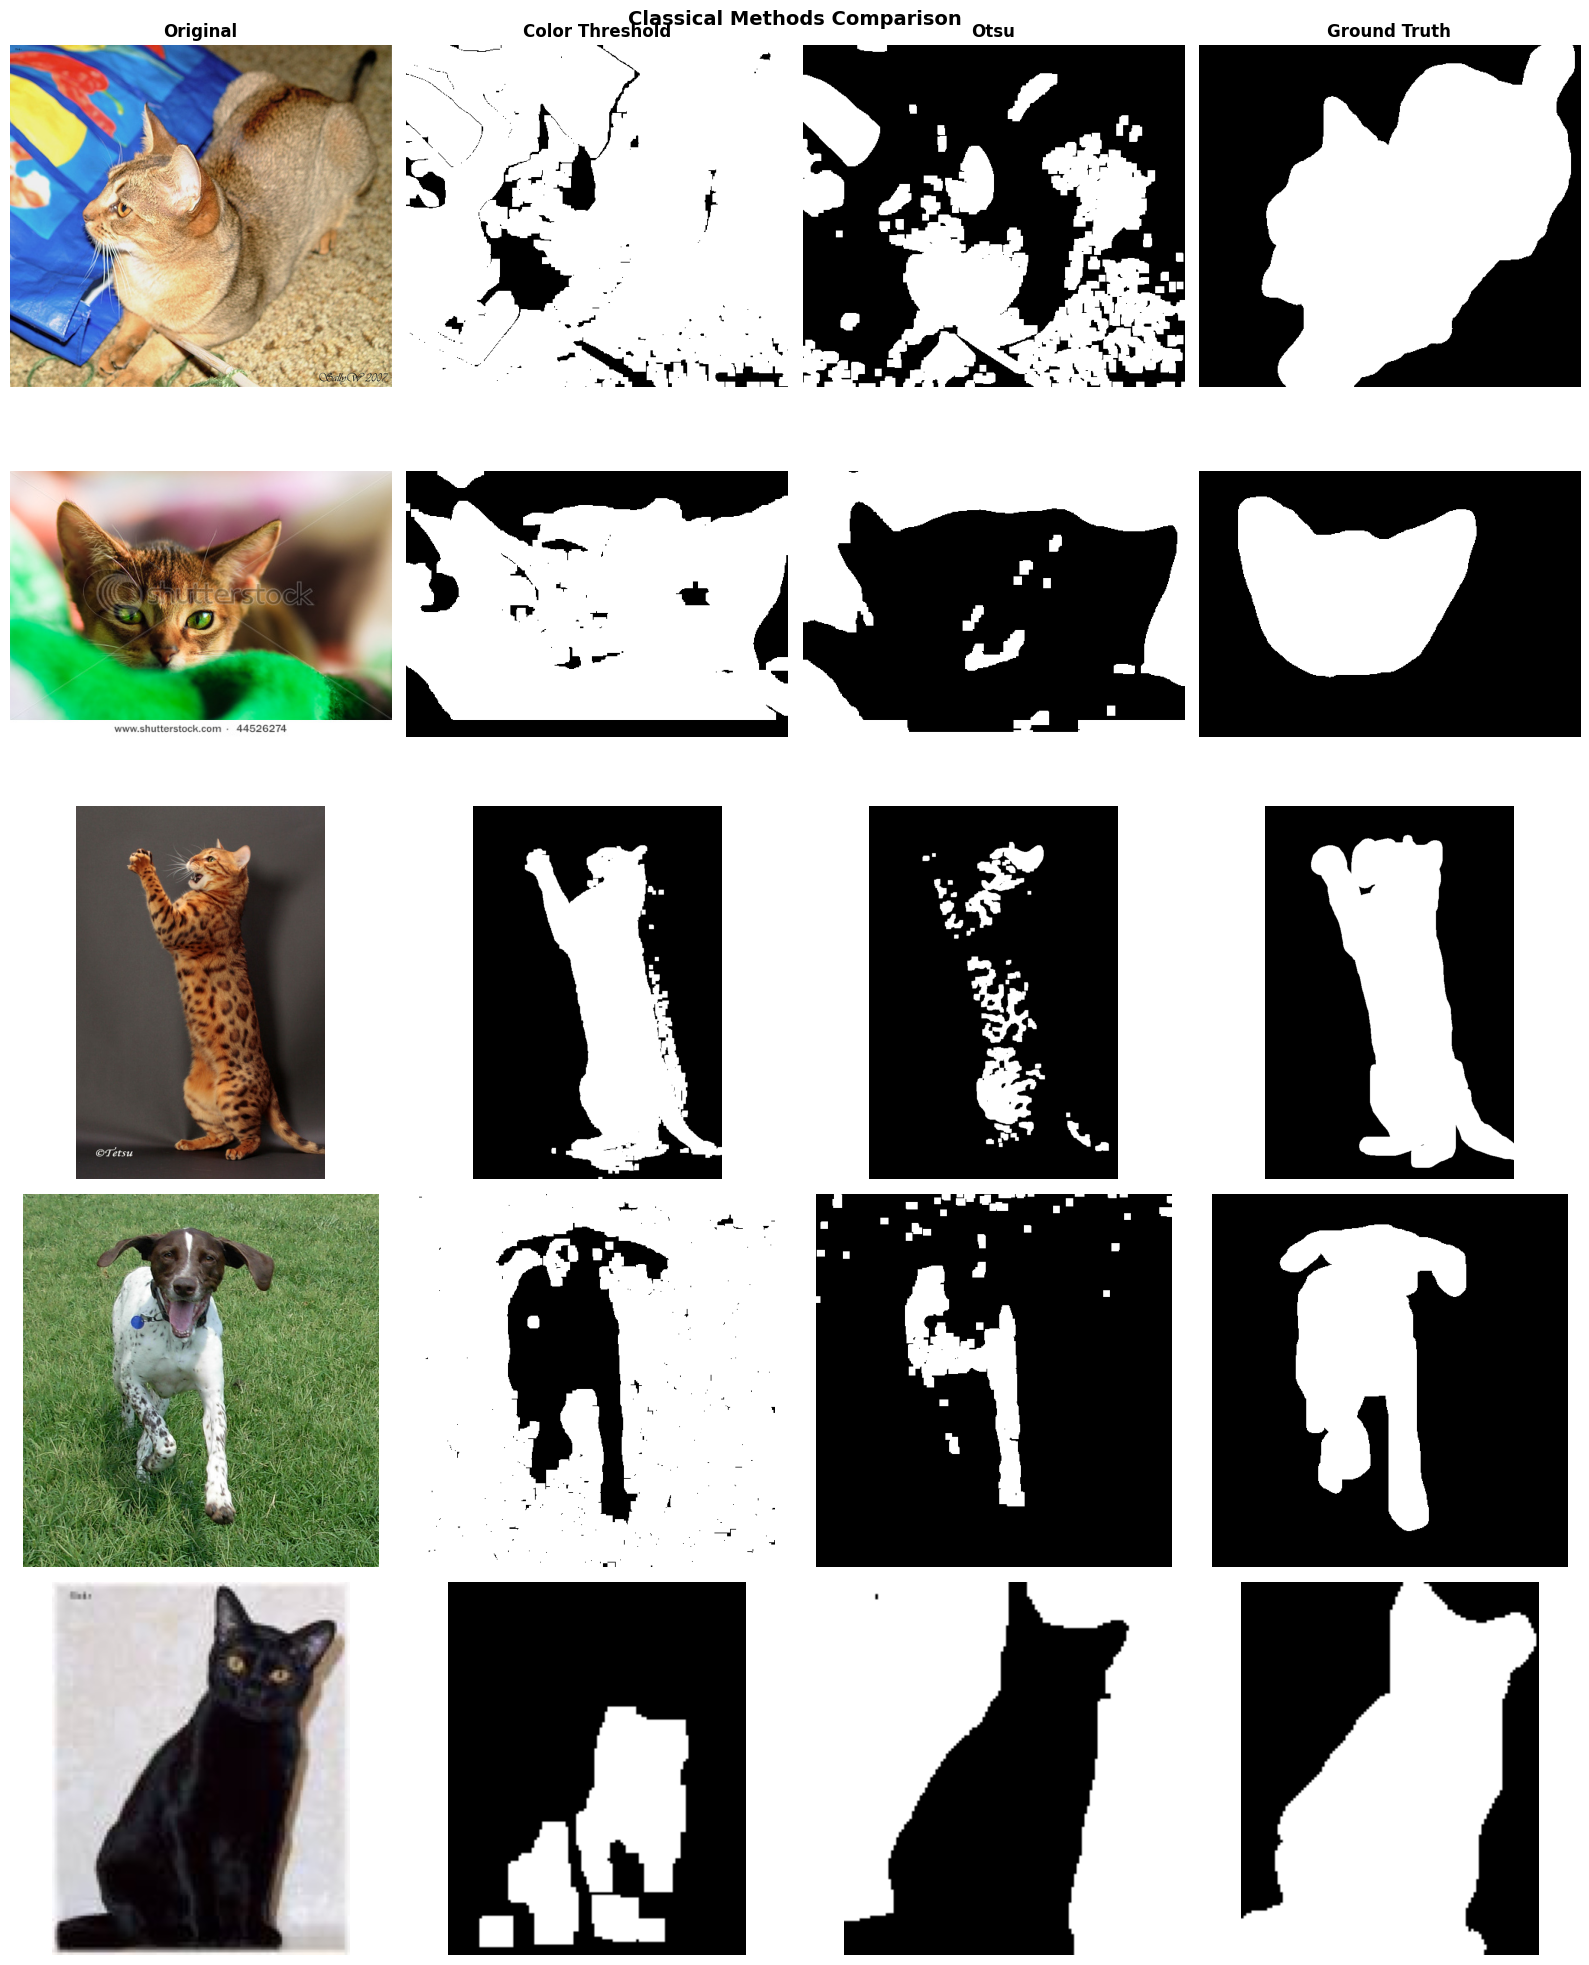

In [14]:

def compare_classical_methods(dataset, n=5):
    """
    Compare color thresholding vs Otsu vs ground truth.
    Grid: n rows x 4 columns (original, color thresh, otsu, ground truth)
    """
    samples = dataset[:n]
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    fig.suptitle("Classical Methods Comparison", fontsize=14, fontweight='bold')
    col_titles = ["Original", "Color Threshold", "Otsu", "Ground Truth"]

    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(samples):
        img   = load_image(img_path)
        gt    = trimap_to_binary(load_mask(mask_path))
        color = morphological_clean(color_threshold_segment(img))
        otsu  = morphological_clean(otsu_segment(img))

        # ── TODO 8 ──────────────────────────────────────────────────────────
        # Column 0: original RGB image
        axes[i, 0].imshow(img)
        axes[i, 0].set_ylabel(img_path.stem, fontsize=7, rotation=0,
                              labelpad=65, va='center')

        # Columns 1-3: binary masks in grayscale
        for j, mask in enumerate([color, otsu, gt], start=1):
            axes[i, j].imshow(mask, cmap="gray", vmin=0, vmax=1)

        # Turn off all axes ticks / borders for every cell in this row
        for j in range(4):
            axes[i, j].axis("off")
        # ────────────────────────────────────────────────────────────────────

    plt.tight_layout()
    plt.show()

compare_classical_methods(dataset, n=5)

---
## Part 3 — SAM ViT-B

We now move to the Segment Anything Model. SAM takes an image and a **prompt** as input and returns a precise mask.

Three prompt strategies, three exercises:
- **3A** — Point prompt: click on the object
- **3B** — Box prompt: draw a bounding box around the object
- **3C** — Automatic: no prompt at all — SAM segments everything


In [15]:
# ── Load SAM ViT-B ───────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = "sam_vit_b_01ec64.pth"

sam = sam_model_registry["vit_b"](checkpoint=CHECKPOINT)
sam.eval()
sam.to(DEVICE)

predictor = SamPredictor(sam)
print(f"✅ SAM ViT-B loaded on {DEVICE}")


✅ SAM ViT-B loaded on cuda


### Exercise 3A — Point Prompt
**The idea:** you click one point on the pet. SAM returns three candidate masks ranked by confidence.  
You then pick the best one.


#### TODO 9 — Encode the image into SAM's embedding
Call `predictor.set_image()` to compute the image embedding.  
This is the expensive step — it runs the ViT-B encoder once per image.


In [16]:
# Load a test image for Part 3
test_img_path, test_mask_path = dataset[0]
test_img  = load_image(test_img_path)
test_gt   = trimap_to_binary(load_mask(test_mask_path))

print(f"Image: {test_img_path.name}  shape: {test_img.shape}")

# ── TODO 9 ──────────────────────────────────────────────────────────────────
# SAM expects a numpy RGB array; load_image already returns that.
predictor.set_image(test_img)
print("✅ Image encoded")
# ───────────────────────────────────────────────────────────────────────────

Image: Abyssinian_107.jpg  shape: (448, 500, 3)
✅ Image encoded


#### TODO 10 — Define a point prompt
Define a single foreground point at the **center of the image**.  
SAM expects points as numpy arrays of shape `(N, 2)` and labels as `(N,)`.  
Label `1` = foreground, `0` = background.


In [17]:
# ── TODO 10 ─────────────────────────────────────────────────────────────────
# Center of the image in (x, y) = (width//2, height//2)
h, w = test_img.shape[:2]
point_coords = np.array([[w // 2, h // 2]])   # shape (1, 2)
point_labels = np.array([1])                  # shape (1,)  — 1 = foreground

print(f"Point coords : {point_coords}")
print(f"Point labels : {point_labels}")

Point coords : [[250 224]]
Point labels : [1]


#### TODO 11 — Run SAM prediction with point prompt
Call `predictor.predict()` with your point coordinates and labels.  
Collect the three output masks and their IoU scores.


In [18]:
# ── TODO 11 ─────────────────────────────────────────────────────────────────
# Call predictor.predict() with:
#   point_coords = point_coords
#   point_labels = point_labels
#   multimask_output = True  ← always True to get 3 masks
# The function returns: masks, scores, logits
# masks shape: (3, H, W) — three binary masks
# scores shape: (3,) — confidence score for each mask

masks, scores, logits = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True,   # always True → returns 3 ranked candidates
)

print(f"Masks shape  : {masks.shape}")
print(f"IoU scores   : {scores.round(3)}")

Masks shape  : (3, 448, 500)
IoU scores   : [0.782 0.703 0.923]


#### TODO 12 — Visualize the three SAM masks
Display the three masks SAM returned, each with its confidence score as title.  
Use a colored semi-transparent overlay on the original image.


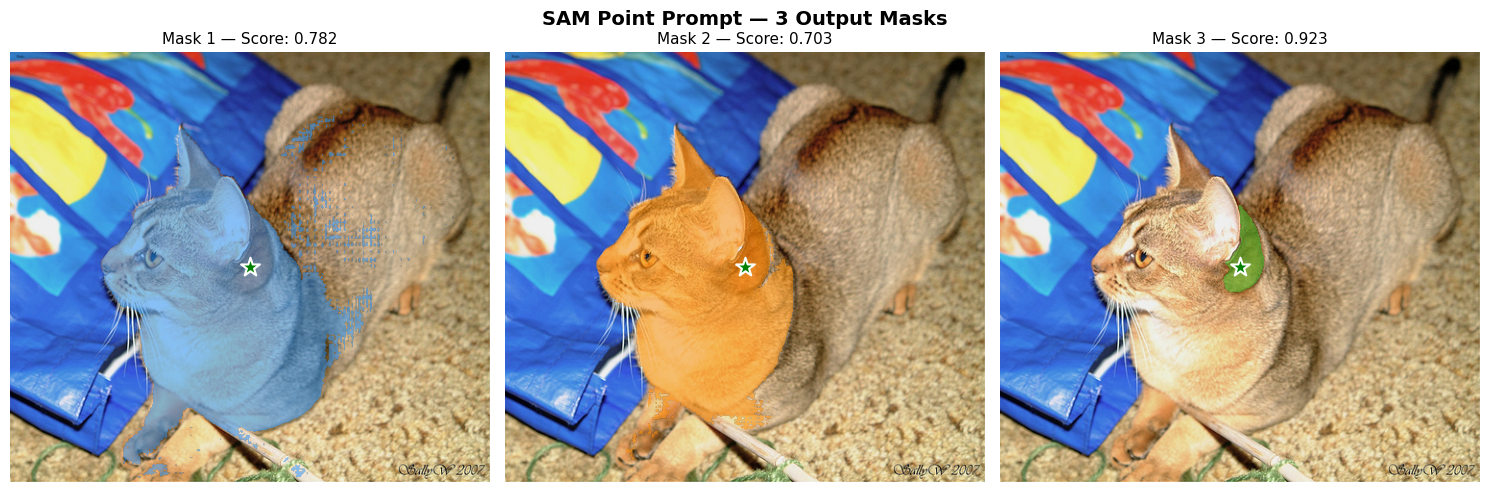

In [19]:
def show_mask(mask, ax, color=None, alpha=0.5):
    """Overlay a binary mask on an existing axes with a given color."""
    if color is None:
        color = np.array([30/255, 144/255, 255/255])
    h, w = mask.shape
    mask_img = np.zeros((h, w, 4))
    mask_img[mask == 1] = [*color, alpha]
    ax.imshow(mask_img)

def show_point(coords, labels, ax):
    """Draw prompt points on axes (green=fg, red=bg)."""
    for coord, label in zip(coords, labels):
        color = 'green' if label == 1 else 'red'
        ax.scatter(coord[0], coord[1], c=color, s=200, marker='*',
                   edgecolors='white', linewidths=1.5, zorder=5)

# ── TODO 12 ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("SAM Point Prompt — 3 Output Masks", fontsize=14, fontweight='bold')

# Assign a distinct colour to each candidate mask
colours = [
    np.array([30/255, 144/255, 255/255]),   # dodger-blue
    np.array([255/255, 140/255, 0/255]),    # orange
    np.array([50/255, 205/255, 50/255]),    # lime-green
]

for i in range(3):
    ax = axes[i]
    ax.imshow(test_img)
    show_mask(masks[i], ax, color=colours[i], alpha=0.5)
    show_point(point_coords, point_labels, ax)
    ax.set_title(f"Mask {i+1} — Score: {scores[i]:.3f}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

###  Reflection — Point Prompt
**Q: SAM returned three masks. Which one is best? Why did SAM return three instead of one?**

*Answer*

The mask with the highest predicted_iou score is typically best ie Mask 3 with score=0,923,  it corresponds to the interpretation SAM is most confident about.

SAM deliberately returns three candidates because a single point is inherently ambiguous: it could refer to a part of the object (e.g. the
cat's head), the whole animal, or the full scene. The three masks cover
these scales (part / whole object / broader region) so the user, or a
downstream selector, can pick the semantically correct one.


---
### Exercise 3B — Box Prompt
**The idea:** instead of a point, we give SAM a bounding box around the pet.  
We compute this box automatically from the ground truth mask.


#### TODO 13 — Compute bounding box from ground truth mask
Find the tight bounding box around the foreground region of the binary mask.  
SAM expects boxes as `[x_min, y_min, x_max, y_max]`.


In [20]:
def mask_to_bbox(binary_mask):
    """
    Compute bounding box of foreground region in a binary mask.
    Args:
        binary_mask: numpy array (H, W) with values 0 and 1
    Returns:
        numpy array [x_min, y_min, x_max, y_max]
    """
    rows, cols = np.where(binary_mask == 1)
    x_min, x_max = int(cols.min()), int(cols.max())
    y_min, y_max = int(rows.min()), int(rows.max())
    return np.array([x_min, y_min, x_max, y_max])

# Test
bbox = mask_to_bbox(test_gt)
print(f"Bounding box: {bbox}")


Bounding box: [ 82   0 491 447]


#### TODO 14 — Run SAM with box prompt
Pass the bounding box to `predictor.predict()` using the `box` argument.


In [21]:
# ── TODO 14 ─────────────────────────────────────────────────────────────────

# predictor still has test_img encoded from TODO 9 — no need to re-encode.
masks, scores, logits = predictor.predict(
    box=bbox[None, :],           # SAM expects shape (1, 4)
    multimask_output=False,      # box prompts → single best mask
)

box_mask = masks[0]
print(f"Box mask shape: {box_mask.shape}, score: {scores[0]:.3f}")



Box mask shape: (448, 500), score: 0.840


#### TODO 15 — Compare point vs box prompt vs ground truth
Display 3 images side by side: **point prompt result | box prompt result | ground truth**  
Do this for 3 different images from the dataset.


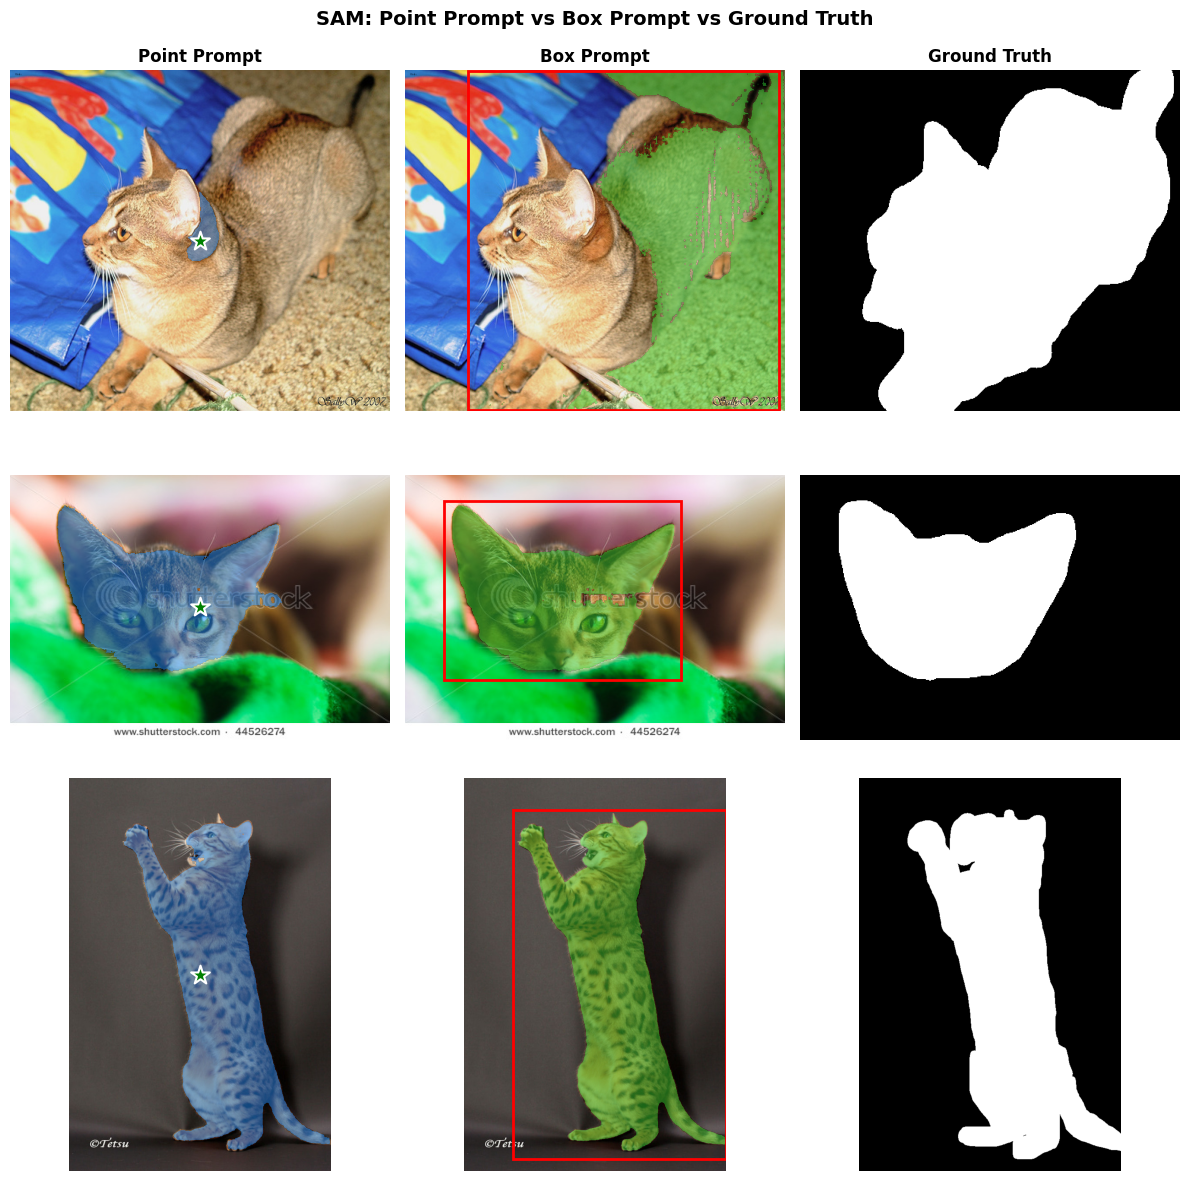

In [22]:
def compare_prompts(dataset, predictor, n=3):
    """
    Compare point prompt vs box prompt vs ground truth for n images.
    """
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle("SAM: Point Prompt vs Box Prompt vs Ground Truth",
                 fontsize=14, fontweight='bold')
    col_titles = ["Point Prompt", "Box Prompt", "Ground Truth"]
    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t, fontsize=12, fontweight='bold')

    for i, (img_path, mask_path) in enumerate(dataset[:n]):
        img = load_image(img_path)
        gt  = trimap_to_binary(load_mask(mask_path))
        box = mask_to_bbox(gt)

        # 1. Encode image once — used for both prompt types
        predictor.set_image(img)

        # 2. Point prompt — center of image, label 1, pick highest-scored mask
        h_i, w_i = img.shape[:2]
        pt_coords = np.array([[w_i // 2, h_i // 2]])
        pt_labels = np.array([1])
        pt_masks, pt_scores, _ = predictor.predict(
            point_coords=pt_coords,
            point_labels=pt_labels,
            multimask_output=True,
        )
        best_pt_mask = pt_masks[np.argmax(pt_scores)]

        # 3. Box prompt — tight GT bbox, single mask output
        bx_masks, _, _ = predictor.predict(
            box=box[None, :],
            multimask_output=False,
        )
        best_bx_mask = bx_masks[0]

        # 4. Display
        # --- point mask column ---
        axes[i, 0].imshow(img)
        show_mask(best_pt_mask, axes[i, 0],
                  color=np.array([30/255, 144/255, 255/255]), alpha=0.5)
        show_point(pt_coords, pt_labels, axes[i, 0])
        axes[i, 0].set_ylabel(img_path.stem, fontsize=7, rotation=0,
                              labelpad=65, va='center')
        axes[i, 0].axis("off")

        # --- box mask column ---
        axes[i, 1].imshow(img)
        show_mask(best_bx_mask, axes[i, 1],
                  color=np.array([50/255, 205/255, 50/255]), alpha=0.5)
        # draw the bounding box rectangle
        rect = patches.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[i, 1].add_patch(rect)
        axes[i, 1].axis("off")

        # --- ground truth column ---
        axes[i, 2].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

compare_prompts(dataset, predictor, n=3)

---
### Exercise 3C — Automatic Mask Generation
**The idea:** no prompt at all. SAM runs on a grid of points and segments everything it finds.


In [23]:
# ── Automatic mask generator — given, do not modify ────────────────────────
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=8,           # reduced for CPU speed
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=500,
)
print(" Automatic mask generator ready")


 Automatic mask generator ready


#### TODO 16 — Run automatic mask generation
Run the mask generator on one image and collect all detected masks.


In [24]:
auto_img_path, auto_mask_path = dataset[1]
auto_img = load_image(auto_img_path)

# ── TODO 16 ─────────────────────────────────────────────────────────────────
auto_masks = mask_generator.generate(auto_img)

print(f"✅ Found {len(auto_masks)} masks automatically")
print(f"Keys in each mask dict: {list(auto_masks[0].keys())}")


✅ Found 7 masks automatically
Keys in each mask dict: ['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box']


#### TODO 17 — Visualize all automatic masks
Write a function that draws each mask with a different random color overlaid on the image.


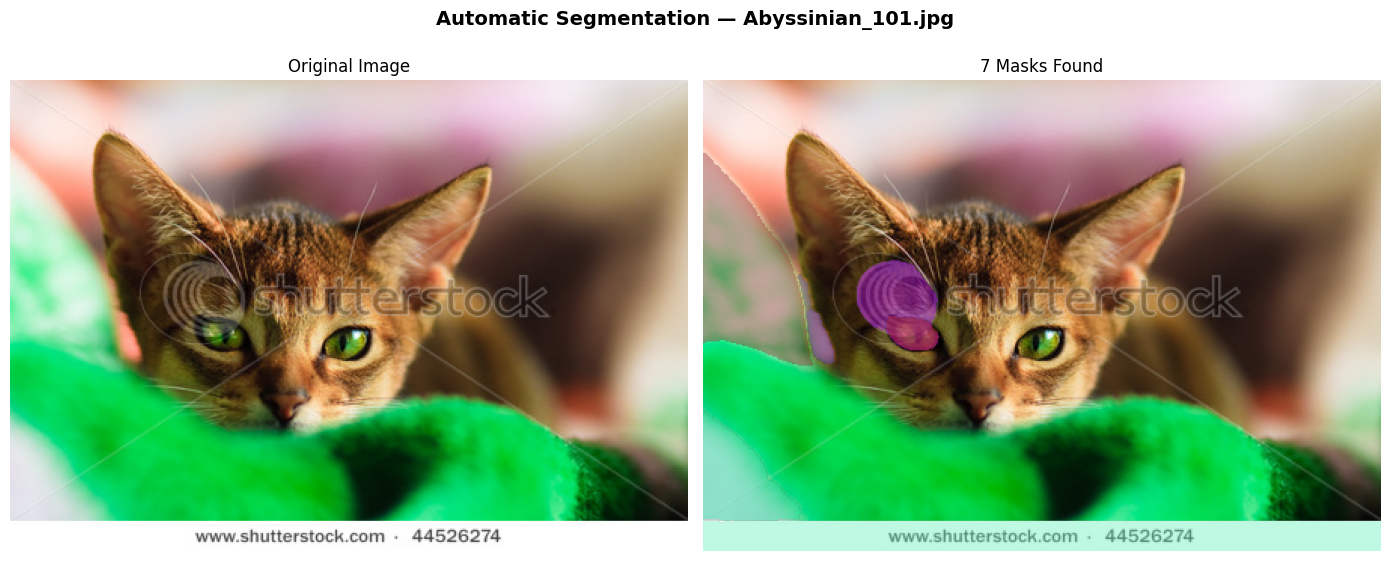

In [25]:
def show_all_masks(image, masks, title="Automatic Masks"):
    """
    Display image with all automatic masks overlaid, each in a different colour.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Left: original image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Right: all masks overlaid
    axes[1].imshow(image)
    axes[1].set_title(f"{len(masks)} Masks Found")

    # Sort masks largest → smallest so smaller masks render on top
    sorted_masks = sorted(masks, key=lambda m: m['area'], reverse=True)

    for m in sorted_masks:
        color = np.random.rand(3)                      # random RGB colour
        show_mask(m['segmentation'], axes[1],
                  color=color, alpha=0.4)

    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

show_all_masks(auto_img, auto_masks, f"Automatic Segmentation — {auto_img_path.name}")

#### TODO 18 — Sort masks by confidence and display top 3
Sort all automatic masks by their `predicted_iou` score (descending).  
Display the top 3 individually with their score and area.


Total masks found: 7


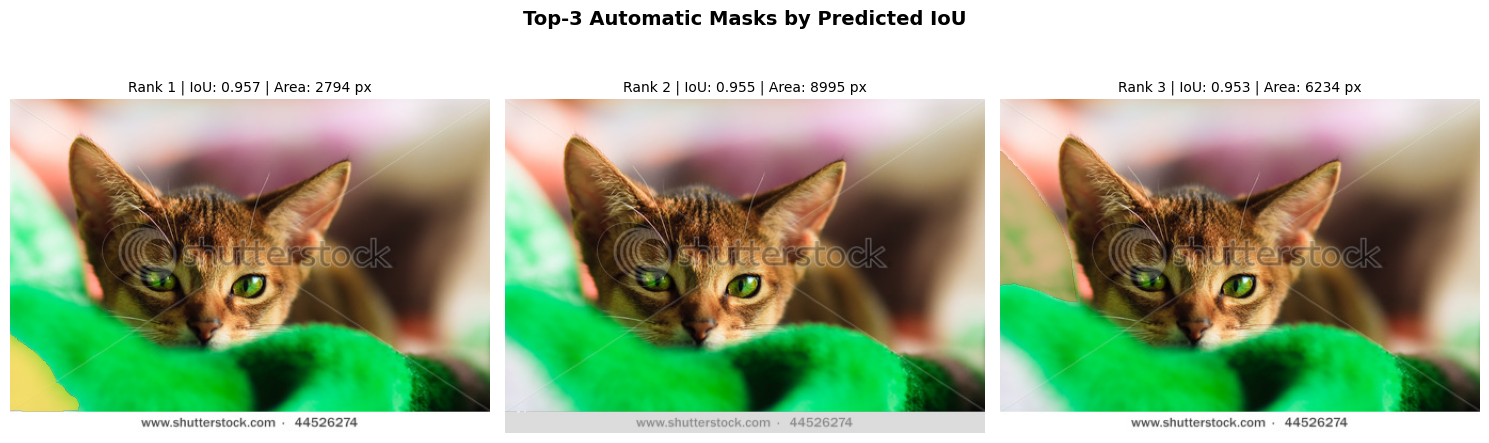

In [26]:
print(f"Total masks found: {len(auto_masks)}")

# Sort by predicted_iou descending
sorted_by_iou = sorted(auto_masks, key=lambda m: m['predicted_iou'], reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Top-3 Automatic Masks by Predicted IoU",
             fontsize=14, fontweight='bold')

top_colours = [
    np.array([255/255, 215/255, 0/255]),    # gold   — rank 1
    np.array([192/255, 192/255, 192/255]),  # silver — rank 2
    np.array([205/255, 127/255, 50/255]),   # bronze — rank 3
]

for i, m in enumerate(sorted_by_iou[:3]):
    ax = axes[i]
    ax.imshow(auto_img)
    show_mask(m['segmentation'], ax, color=top_colours[i], alpha=0.55)
    ax.set_title(
        f"Rank {i+1} | IoU: {m['predicted_iou']:.3f} | Area: {m['area']} px",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### ✍️ Reflection — Automatic Generation
**Q: SAM found N masks automatically. Are all of them meaningful?  
What determines whether a region gets its own mask?**

*Answer*

Not all masks are semantically meaningful: SAM is a class-agnostic detector of *any* coherent region, so it will segment background patches, shadows, or texture regions that a human would ignore. Whether a region gets its own mask is determined by three configurable thresholds used during automatic generation:
  1. pred_iou_thresh  — only keep masks whose predicted IoU (self-
     consistency between mask and its prompt) exceeds this value.
  2. stability_score_thresh — keeps only masks that remain stable
     when the confidence threshold is varied slightly.
  3. min_mask_region_area — filters out very small blobs that are
     likely noise rather than real objects.

Even after filtering, small high-contrast patches (e.g. a collar tag,
a watermark, a highlight) can meet all criteria and appear as separate
masks. In practice, a post-processing step that matches masks to a
known class (e.g. "pet") is needed to isolate the segment of interest.


---
## Part 4 — Metrics: Measuring What We See

You have seen IoU and DICE in the lecture. Now implement them from scratch  
and use them to rigorously compare all three segmentation approaches.

Recall:
$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

$$\text{DICE}(A, B) = \frac{2|A \cap B|}{|A| + |B|}$$


### TODO 19 — Implement IoU from scratch


In [32]:
def compute_iou(pred_mask, gt_mask):
    """
    Compute Intersection over Union between two binary masks.
    Args:
        pred_mask: numpy array (H, W) with bool / 0-1 values
        gt_mask  : numpy array (H, W) with bool / 0-1 values
    Returns:
        float in [0, 1]
    """
    # ── TODO 19 ─────────────────────────────────────────────────────────────
    # Cast to bool so bitwise AND / OR work correctly on any int dtype
    pred = pred_mask.astype(bool)
    gt   = gt_mask.astype(bool)

    intersection = np.logical_and(pred, gt).sum()   # |A ∩ B|
    union        = np.logical_or(pred, gt).sum()    # |A ∪ B|

    # Guard against the edge case where both masks are empty
    if union == 0:
        return 1.0   # both empty → perfect agreement

    return float(intersection) / float(union)
    # ────────────────────────────────────────────────────────────────────────

# Sanity checks
perfect = np.array([[1, 1, 0], [0, 1, 0]])
assert compute_iou(perfect, perfect) == 1.0, "Perfect overlap should give IoU=1"
empty = np.zeros_like(perfect)
assert compute_iou(perfect, empty)   == 0.0, "No overlap should give IoU=0"
print("✅ IoU sanity checks passed")


✅ IoU sanity checks passed


### TODO 20 — Implement DICE from scratch


In [35]:
def compute_dice(pred_mask, gt_mask):
    """
    Compute DICE score between two binary masks.
    Args:
        pred_mask: numpy array (H, W) with bool / 0-1 values
        gt_mask  : numpy array (H, W) with bool / 0-1 values
    Returns:
        float in [0, 1]
    """
    # ── TODO 20 ─────────────────────────────────────────────────────────────
    pred = pred_mask.astype(bool)
    gt   = gt_mask.astype(bool)

    intersection = np.logical_and(pred, gt).sum()   # |A ∩ B|
    denominator  = pred.sum() + gt.sum()             # |A| + |B|

    # Guard: both masks empty → perfect agreement
    if denominator == 0:
        return 1.0

    return float(2 * intersection) / float(denominator)
    # ────────────────────────────────────────────────────────────────────────

# Sanity checks
assert compute_dice(perfect, perfect) == 1.0, "Perfect overlap should give DICE=1"
assert compute_dice(perfect, empty)   == 0.0, "No overlap should give DICE=0"
print("✅ DICE sanity checks passed")

# Quick relationship check: DICE >= IoU always holds
half = np.array([[1, 0], [0, 0]])
iou_half  = compute_iou(half, perfect[:1, :2])
dice_half = compute_dice(half, perfect[:1, :2])
print(f"   IoU={iou_half:.3f}  DICE={dice_half:.3f}  (DICE >= IoU as expected)")

✅ DICE sanity checks passed
   IoU=0.250  DICE=0.667  (DICE >= IoU as expected)


### TODO 21 — Evaluate all three methods on 50 images
Compute mean IoU and mean DICE for:
- Color thresholding
- SAM point prompt (center point)
- SAM box prompt (from ground truth bbox)


In [36]:
def evaluate_method(dataset, predictor, method="color", n=50):
    """
    Evaluate a segmentation method on n images.
    Returns dict with 'iou' and 'dice' lists.
    """
    ious, dices = [], []
    print(f"Evaluating: {method} on {n} images ...")

    for img_path, mask_path in dataset[:n]:
        img = load_image(img_path)
        gt  = trimap_to_binary(load_mask(mask_path))

        if method == "color":
            pred = morphological_clean(color_threshold_segment(img))

        elif method == "otsu":
            pred = morphological_clean(otsu_segment(img))

        elif method == "sam_point":
            # ── TODO 21a ────────────────────────────────────────────────────
            # Encode image, run center-point prompt, pick highest-scored mask
            predictor.set_image(img)
            h_i, w_i = img.shape[:2]
            pt_coords = np.array([[w_i // 2, h_i // 2]])
            pt_labels = np.array([1])
            pt_masks, pt_scores, _ = predictor.predict(
                point_coords=pt_coords,
                point_labels=pt_labels,
                multimask_output=True,
            )
            # argmax selects the mask SAM is most confident about
            pred = pt_masks[np.argmax(pt_scores)].astype(np.uint8)
            # ────────────────────────────────────────────────────────────────

        elif method == "sam_box":
            # ── TODO 21b ────────────────────────────────────────────────────
            # Encode image, derive bbox from GT, run box prompt
            predictor.set_image(img)
            box = mask_to_bbox(gt)
            bx_masks, _, _ = predictor.predict(
                box=box[None, :],          # shape (1, 4)
                multimask_output=False,    # single best mask for box prompt
            )
            pred = bx_masks[0].astype(np.uint8)
            # ────────────────────────────────────────────────────────────────

        # Resize pred to gt size if shapes diverged (safety guard)
        if pred.shape != gt.shape:
            pred = cv2.resize(pred.astype(np.uint8),
                              (gt.shape[1], gt.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

        ious.append(compute_iou(pred.astype(bool),  gt.astype(bool)))
        dices.append(compute_dice(pred.astype(bool), gt.astype(bool)))

    return {"iou": ious, "dice": dices}

In [37]:

# ── TODO 21c — Run all four evaluations ─────────────────────────────────────
results = {
    "Color Threshold": evaluate_method(dataset, predictor, method="color"),
    "Otsu"           : evaluate_method(dataset, predictor, method="otsu"),
    "SAM Point"      : evaluate_method(dataset, predictor, method="sam_point"),
    "SAM Box"        : evaluate_method(dataset, predictor, method="sam_box"),
}

# ── Results table (provided — runs once results dict is filled) ──────────────
print("\n" + "=" * 55)
print(f"{'Method':<20} {'Mean IoU':>10} {'Mean DICE':>10}")
print("=" * 55)
for method_name, res in results.items():
    print(f"{method_name:<20} {np.mean(res['iou']):>10.3f} "
          f"{np.mean(res['dice']):>10.3f}")
print("=" * 55)

Evaluating: color on 50 images ...
Evaluating: otsu on 50 images ...
Evaluating: sam_point on 50 images ...
Evaluating: sam_box on 50 images ...

Method                 Mean IoU  Mean DICE
Color Threshold           0.308      0.437
Otsu                      0.132      0.218
SAM Point                 0.556      0.635
SAM Box                   0.740      0.831


### TODO 22 — Plot results
Two plots:
1. **Bar chart** comparing mean IoU across all methods
2. **Scatter plot** of per-image IoU: SAM point vs SAM box (one dot per image)


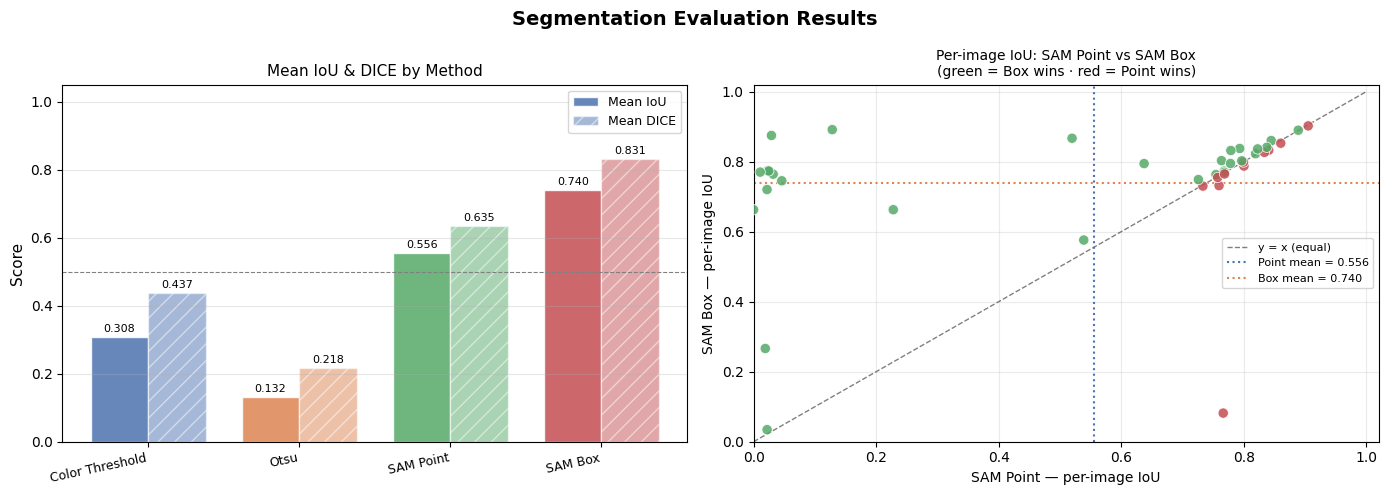

In [40]:

def plot_results(results):
    """
    Plot 1: grouped bar chart of mean IoU and mean DICE per method.
    Plot 2: scatter plot — per-image IoU, SAM Point vs SAM Box.
    """
    method_names = list(results.keys())
    mean_ious  = [np.mean(v["iou"])  for v in results.values()]
    mean_dices = [np.mean(v["dice"]) for v in results.values()]
    bar_colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Segmentation Evaluation Results", fontsize=14, fontweight='bold')

    # ── TODO 22a — Grouped bar chart (IoU + DICE side by side) ──────────────
    x      = np.arange(len(method_names))
    width  = 0.38

    bars_iou  = axes[0].bar(x - width / 2, mean_ious,  width,
                             label="Mean IoU",  color=bar_colours, alpha=0.85,
                             edgecolor="white")
    bars_dice = axes[0].bar(x + width / 2, mean_dices, width,
                             label="Mean DICE", color=bar_colours, alpha=0.50,
                             edgecolor="white", hatch="//")

    # Annotate bar heights
    for bar in list(bars_iou) + list(bars_dice):
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                     f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(method_names, rotation=12, ha="right", fontsize=9)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Score", fontsize=11)
    axes[0].set_title("Mean IoU & DICE by Method", fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].axhline(0.5, color="grey", linestyle="--", linewidth=0.8,
                    label="0.5 baseline")
    axes[0].grid(axis="y", alpha=0.3)
    # ────────────────────────────────────────────────────────────────────────
     # ── TODO 22b — Scatter plot: per-image IoU, SAM Point vs SAM Box ────────
    point_ious = results["SAM Point"]["iou"]
    box_ious   = results["SAM Box"]["iou"]

    # Colour points by which method wins on each image
    colours = ["#55A868" if b > p else "#C44E52"
               for p, b in zip(point_ious, box_ious)]

    axes[1].scatter(point_ious, box_ious, c=colours, s=55,
                    edgecolors="white", linewidths=0.6, alpha=0.85, zorder=3)

    # Diagonal y = x reference line
    lims = [0, 1]
    axes[1].plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="y = x (equal)")

    # Mean lines
    axes[1].axvline(np.mean(point_ious), color="#4C72B0", linestyle=":",
                    linewidth=1.5, label=f"Point mean = {np.mean(point_ious):.3f}")
    axes[1].axhline(np.mean(box_ious), color="#DD8452", linestyle=":",
                    linewidth=1.5, label=f"Box mean = {np.mean(box_ious):.3f}")

    axes[1].set_xlim(0, 1.02)
    axes[1].set_ylim(0, 1.02)
    axes[1].set_xlabel("SAM Point — per-image IoU", fontsize=10)
    axes[1].set_ylabel("SAM Box — per-image IoU",   fontsize=10)
    axes[1].set_title("Per-image IoU: SAM Point vs SAM Box\n"
                      "(green = Box wins · red = Point wins)", fontsize=10)
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.25)
    # ────────────────────────────────────────────────────────────────────────

    plt.tight_layout()
    plt.show()

plot_results(results)


### TODO 23 — Failure analysis
Find the 3 images where SAM box prompt got the **lowest IoU**.  
Display each with: original image | SAM box mask | ground truth | IoU score as title.  
Write 3 sentences below explaining what went wrong visually.





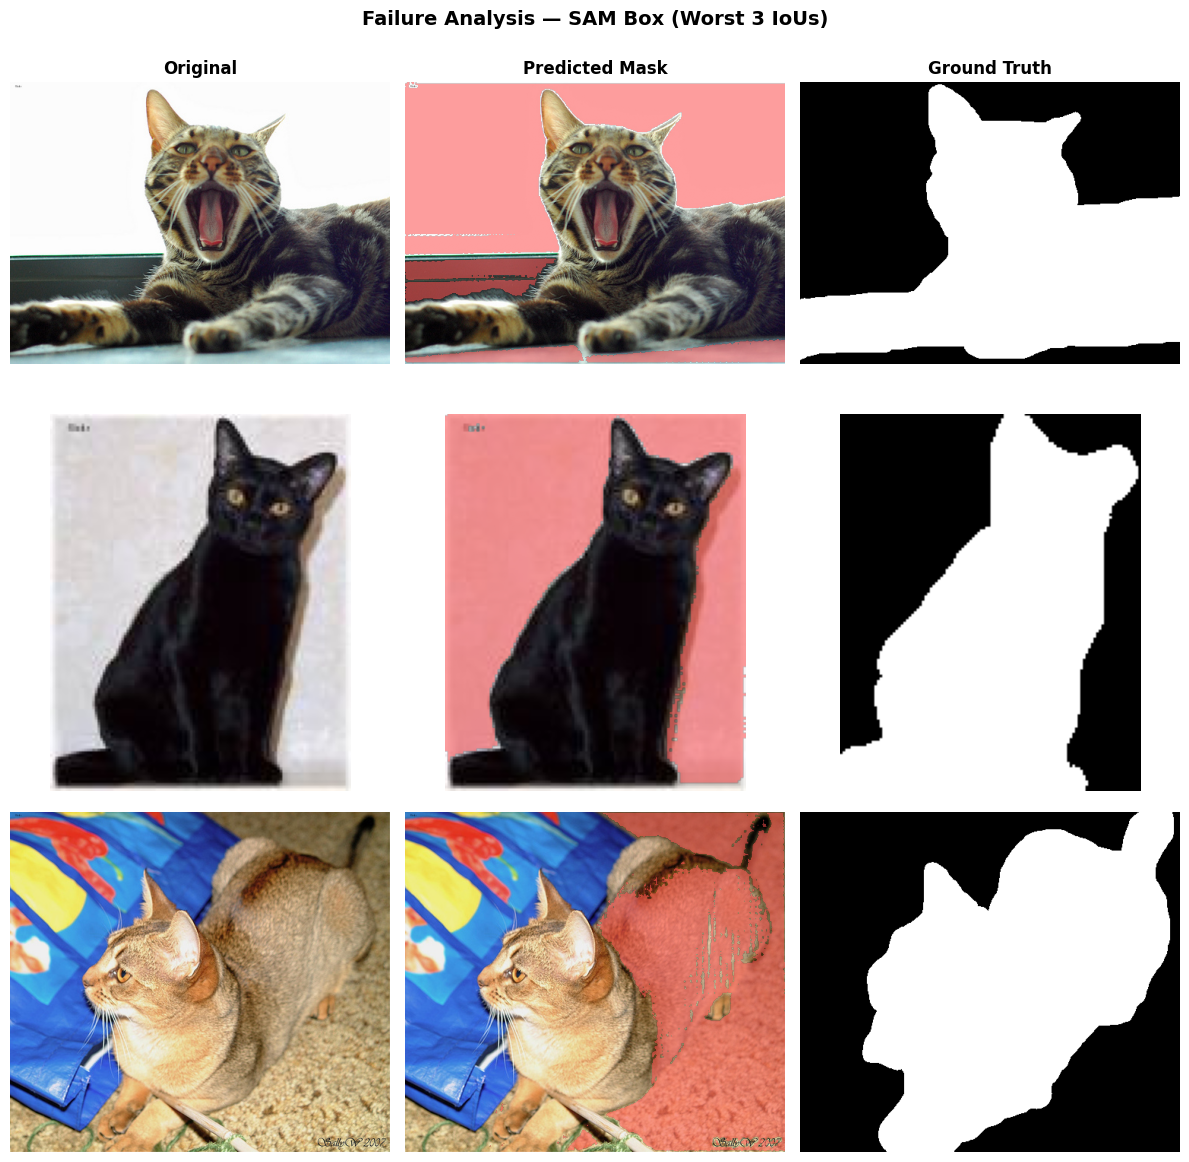

In [41]:

def failure_analysis(dataset, predictor, results, method_key="SAM Box", n_failures=3):
    """
    Find the n images with the lowest IoU for the given method and
    display each as: original image | predicted mask | ground truth.
    Titles show the IoU score.
    """
    # ── TODO 23 ─────────────────────────────────────────────────────────────
    # 1. Rank all images by IoU (ascending) to find the worst predictions
    ious      = results[method_key]["iou"]
    worst_idx = np.argsort(ious)[:n_failures]   # indices of n lowest IoUs

    # Method string used in evaluate_method()
    method_str = {
        "Color Threshold": "color",
        "Otsu"           : "otsu",
        "SAM Point"      : "sam_point",
        "SAM Box"        : "sam_box",
    }[method_key]

    fig, axes = plt.subplots(n_failures, 3, figsize=(12, 4 * n_failures))
    fig.suptitle(f"Failure Analysis — {method_key} (Worst {n_failures} IoUs)",
                 fontsize=14, fontweight='bold')

    for col_j, col_title in enumerate(["Original", "Predicted Mask", "Ground Truth"]):
        axes[0, col_j].set_title(col_title, fontsize=12, fontweight='bold')

    for row_i, idx in enumerate(worst_idx):
        img_path, mask_path = dataset[idx]
        img  = load_image(img_path)
        gt   = trimap_to_binary(load_mask(mask_path))
        iou_score = ious[idx]

        # Re-generate the prediction for this image
        if method_str == "color":
            pred = morphological_clean(color_threshold_segment(img))
        elif method_str == "otsu":
            pred = morphological_clean(otsu_segment(img))
        elif method_str == "sam_point":
            predictor.set_image(img)
            h_i, w_i = img.shape[:2]
            pt_coords = np.array([[w_i // 2, h_i // 2]])
            pt_labels = np.array([1])
            pt_masks, pt_scores, _ = predictor.predict(
                point_coords=pt_coords,
                point_labels=pt_labels,
                multimask_output=True,
            )
            pred = pt_masks[np.argmax(pt_scores)].astype(np.uint8)
        elif method_str == "sam_box":
            predictor.set_image(img)
            box = mask_to_bbox(gt)
            bx_masks, _, _ = predictor.predict(
                box=box[None, :],
                multimask_output=False,
            )
            pred = bx_masks[0].astype(np.uint8)

        if pred.shape != gt.shape:
            pred = cv2.resize(pred.astype(np.uint8),
                              (gt.shape[1], gt.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

        # 2. Column 0: original image
        axes[row_i, 0].imshow(img)
        axes[row_i, 0].set_ylabel(f"#{idx} — {img_path.stem}",
                                   fontsize=7, rotation=0,
                                   labelpad=70, va='center')
        axes[row_i, 0].set_xlabel(f"IoU = {iou_score:.3f}", fontsize=9,
                                   color="red", fontweight='bold')

        # 3. Column 1: predicted mask overlaid on image
        axes[row_i, 1].imshow(img)
        show_mask(pred, axes[row_i, 1],
                  color=np.array([255/255, 80/255, 80/255]), alpha=0.55)

        # 4. Column 2: ground truth mask
        axes[row_i, 2].imshow(gt, cmap="gray", vmin=0, vmax=1)

        for col_j in range(3):
            axes[row_i, col_j].axis("off")

    plt.tight_layout()
    plt.show()

failure_analysis(dataset, predictor, results)

### ✍️ Failure Analysis — Written Response
**Look at the 3 failure cases above. Write 3 sentences explaining what went wrong and why.**

*Answer*

In all three failure cases, SAM's box prompt segmented the background instead of the pet, producing a mask that covers the empty space around the animal rather than the animal itself. This happens because the pets have very low contrast against their backgrounds — the tabby blends into the grey surface, the black Bombay disappears against the white wall, and the Abyssinian's fur matches the floor — leaving SAM without a clear boundary signal. The core issue is that a bounding box is a spatial hint, not a semantic one: when the background is more visually salient than the pet inside the box, SAM's confidence inverts and it returns the complement of the correct mask.
